In [40]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score


Let's get the Dataset!

In [41]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
CSV_path = path + r"\creditcard.csv"
df = pd.read_csv(CSV_path)

Let's do some EDA first, just to figure out what's going on heh

In [42]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.describe())
df["Class"].value_counts()

(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170  

Class
0    284315
1       492
Name: count, dtype: int64

Ok one good thing about this dataset, is that it's literally all numeric and it's an easy binary classification problem! 
... or is it!

I'm gonna train the model here without much preprocessing (since the dataset was already processed) let's see how it will fair

In [43]:
#Remember to split!
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='aucpr')
model.fit(X_train, y_train)

y_predictions = model.predict(X_test)
y_probabilities = model.predict_proba(X_test)[:,1]

Ok this next part is about to shock you

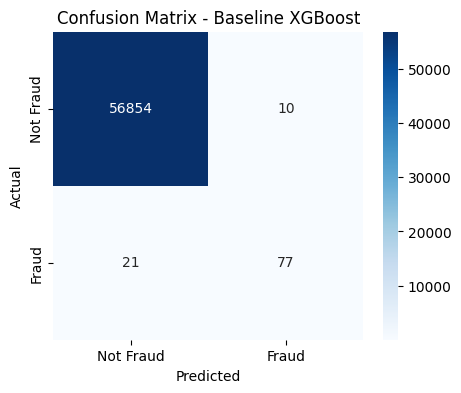

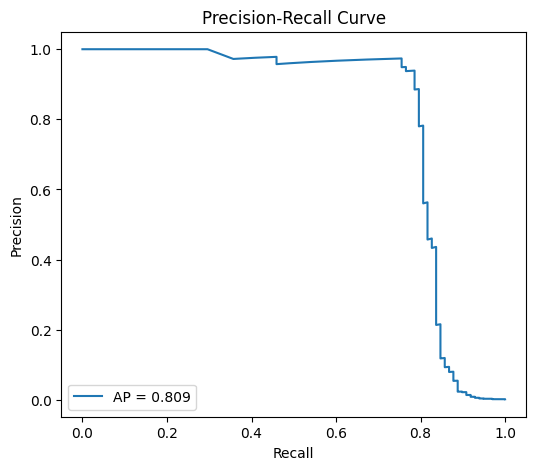

In [45]:
cm = confusion_matrix(y_test, y_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline XGBoost')
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_probabilities)
ap_score = average_precision_score(y_test, y_probabilities)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

"My model is so good" until you realize, it's good at predicting class 0s, but we want it to predict class 1s where fraud actually happens... so what can we do? We use something called scale_pos_weight (ratio of negative to positive class count)

In [46]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='aucpr', scale_pos_weight=scale_pos_weight)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]



Now we do the same thing!

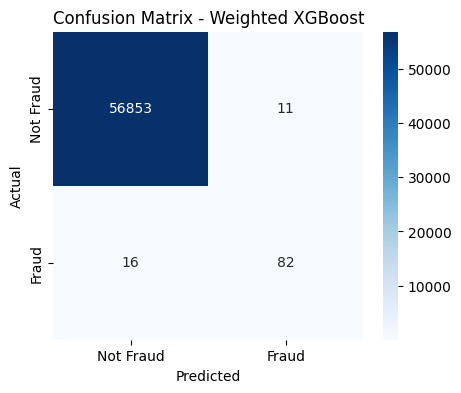

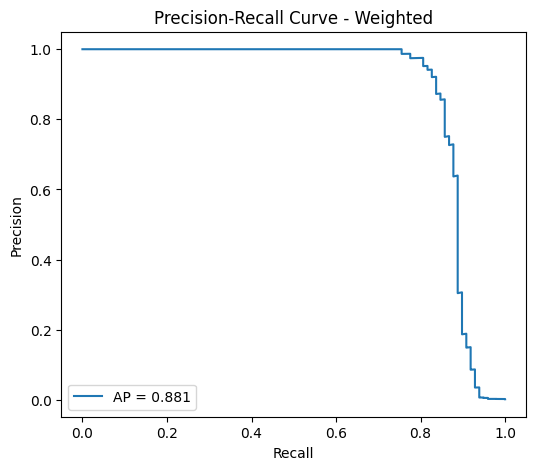

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Weighted XGBoost')
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Weighted')
plt.legend()
plt.show()